## Figure A7 (Restricted) - Tahoe DEG Boxplot

All models restricted to compounds with LPM embeddings (~141 compounds).
Includes new ECFP:2 and LPM embeddings from `tahoe_sci_op3_updated.pkl`.

In [1]:
import pandas as pd
import seaborn as sns
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

## Load scores and plotting metadata

In [2]:
results_path = "/home/matthew-mella/valinor/foundation-models-perturbation/results/"

df = pd.read_csv(results_path + "scores/tahoe_deg_restricted.csv", index_col=0)
print(f"Loaded {len(df)} rows, {df['name'].nunique()} unique models")
df.head()

Loaded 6975 rows, 31 unique models


,dataset,fold,metrics,name,roc_auc,average_precision,f1_score,recall,precision,f1_classwise,f1_score_nans_are_zeros,primary_metric,cell_line,quantile
0,expression/pert_prediction_tahoe_deg,CVCL_0023.0,"{'roc_auc': 0.29145151376724243, 'average_prec...",random,0.291452,0.651498,0.600973,0.606254,0.606192,NaN,NaN,f1_score,CVCL_0023,NaN
1,expression/pert_prediction_tahoe_deg,CVCL_0023.0,"{'roc_auc': 0.4512379467487335, 'average_preci...",pca,0.451238,0.807979,0.719977,0.732033,0.728026,NaN,NaN,f1_score,CVCL_0023,NaN
2,expression/pert_prediction_tahoe_deg,CVCL_0023.0,"{'roc_auc': 0.2811363935470581, 'average_preci...",ECFP:2_pkl,0.281136,0.647242,0.600074,0.606205,0.601889,NaN,NaN,f1_score,CVCL_0023,NaN
3,expression/pert_prediction_tahoe_deg,CVCL_0023.0,"{'roc_auc': 0.3189498484134674, 'average_preci...",LPM_emb,0.318950,0.666752,0.612681,0.620037,0.616450,NaN,NaN,f1_score,CVCL_0023,NaN
4,expression/pert_prediction_tahoe_deg,CVCL_0023.0,"{'roc_auc': 0.29229801893234253, 'average_prec...",ChemBERTa-77M-MTR,0.292298,0.654297,0.606128,0.610776,0.613332,NaN,NaN,f1_score,CVCL_0023,NaN


In [3]:
# Load plotting metadata (palette, hue order, mpl params)
with open(results_path + "metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

model_type_palette = fig_index['drugs_model_type_palette']
hue_order = fig_index['drugs_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])
mpl.rcParams.update({"legend.loc": "upper right"})

## Build method map and plot

In [4]:
# Build method_map from fig_index["tahoe_deg"]
# Names in the CSV already match fig_index keys (short names like "chatgpt", "prior", etc.)
method_map = dict(fig_index["tahoe_deg"])

# Add new pkl embedding models
method_map["ECFP:2_pkl"] = ["ECFP:2 (LPM)", "Molecule Structure"]
method_map["LPM_emb"] = ["LPM Embedding", "Molecule Structure"]

# Rename baselines to match CSV naming (prior -> "Train Mean", etc.)
# "prior" in tahoe_deg maps to "Train Mean" which is correct

print(f"Models in method_map: {len(method_map)}")
for k, v in method_map.items():
    print(f"  {k} -> {v[0]} ({v[1]})")

Models in method_map: 29
  prior -> Train Mean (Negative Control)
  no_change -> No Change (Negative Control)
  random -> Random Embeddings (Negative Control)
  ChemBERTa-77M-MLM -> ChemBERTa-77M-MLM (SMILES Transformer)
  ChemBERTa-77M-MTR -> ChemBERTa-77M-MTR (SMILES Transformer)
  MiniMol -> MiniMol (SMILES Transformer)
  MolT5 -> MolT5 (SMILES Transformer)
  boltz_affinity_pred_value_fragment -> Boltz (Fragment) (Protein Affinity)
  boltz_affinity_pred_value_protein -> Boltz (Protein) (Protein Affinity)
  chatgpt -> ChatGPT (LLM)
  maccs -> MACCS (Molecule Structure)
  topological -> Topological (Molecule Structure)
  secfp -> SECFP (Molecule Structure)
  ecfp:2 -> ECFP:2 (Molecule Structure)
  avalon -> Avalon (Molecule Structure)
  erg -> ErG (Molecule Structure)
  unimol2-570m-H -> Uni-Mol2 (570M-H) (Molecule Structure)
  scPRINT_Norman_K-562_controls_(D=512)_concat -> scPRINT - Norman (Gene Target)
  TranscriptFormer_Norman_K-562_controls_(D=2048)_concat -> TranscriptFormer - N

Rows after filtering to known models: 6300
Best non-control model: AIDO.Cell 100M - Norman (median F1=0.6641, type=Gene Target)


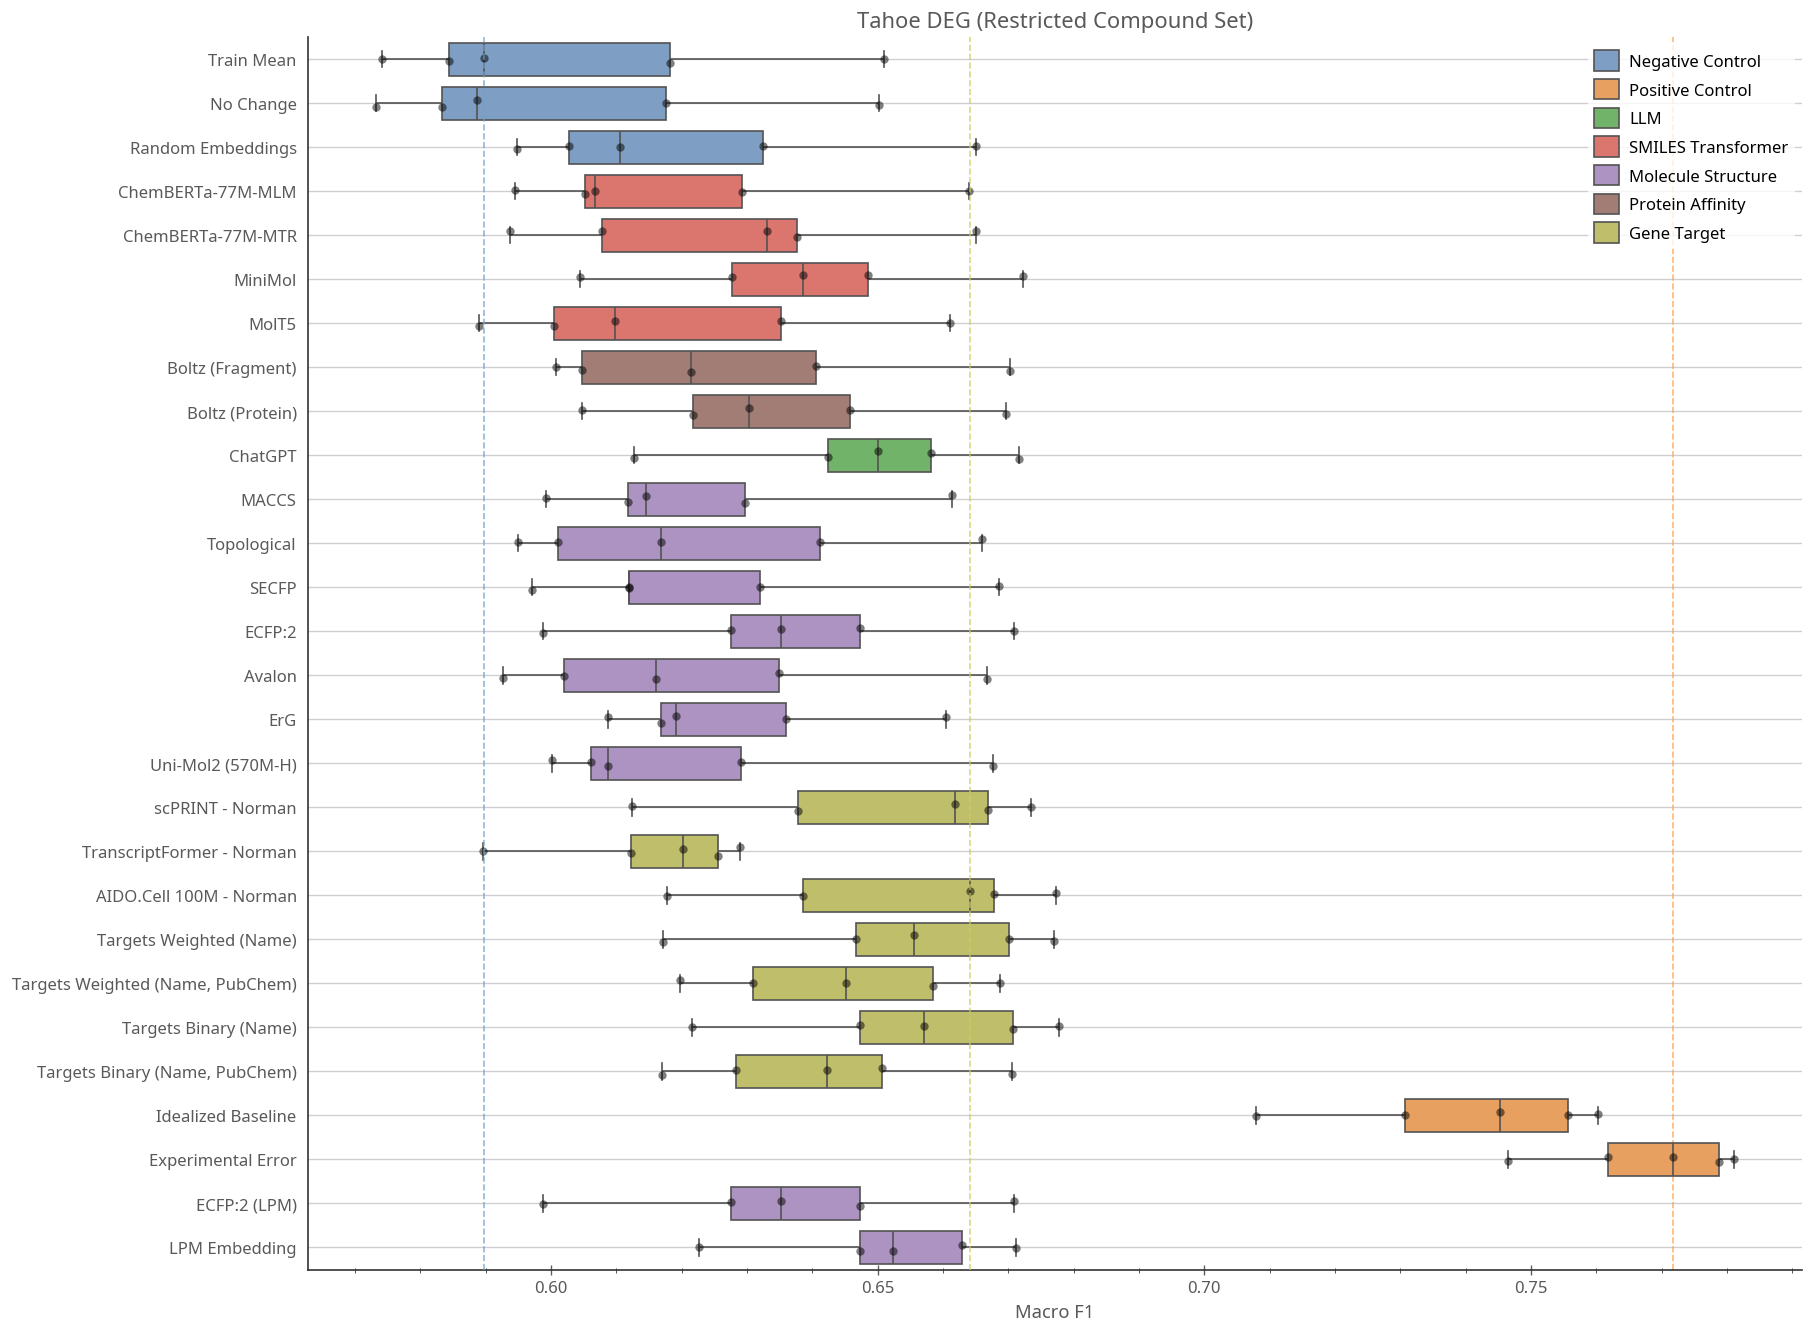

In [5]:
fig, ax = plt.subplots(figsize=(15, 11), constrained_layout=True)

df_subset = df[df["name"].isin(method_map)].copy()
print(f"Rows after filtering to known models: {len(df_subset)}")

df_subset["fold"] = df_subset["fold"].apply(
    lambda x: x if "." not in str(x) else x.split(".")[1]
)
df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

# Aggregate: mean f1_score across cell lines, per fold
df_subset = df_subset.groupby(["fold", "name", "Model type"])["f1_score"].mean().reset_index()

present_hues = [
    h for h in hue_order
    if h in df_subset["Model type"].unique()
]

# Order: follow method_map order, only include names present in data
name_order = [name for name, _ in method_map.values() if name in df_subset["name"].values]

# Boxplot
g = sns.boxplot(
    data=df_subset,
    y="name",
    order=name_order,
    hue="Model type",
    hue_order=present_hues,
    x="f1_score",
    ax=ax,
    whis=(0, 100),
    width=0.75,
    palette=model_type_palette,
)

# Overlay stripplot
sns.stripplot(
    data=df_subset,
    y="name",
    order=name_order,
    color="black",
    alpha=0.5,
    s=5,
    x="f1_score",
    ax=ax,
)

# Decorate
g.grid(axis="y")
g.set(ylabel=None, title="Tahoe DEG (Restricted Compound Set)")
g.set_xlabel('Macro F1')
g.legend(title=None)

# Get the best performing model (excluding controls and fusion)
best_mask = (
    (df_subset["Model type"] != "Positive Control") &
    (df_subset["Model type"] != "Negative Control") &
    (df_subset["Model type"] != "Fusion")
)
best_group = (
    df_subset.loc[best_mask]
    .groupby("name")["f1_score"]
    .median()
)
best_name = best_group.idxmax()
best_level = best_group.loc[best_name]
best_model_type = (
    df_subset.loc[df_subset["name"] == best_name, "Model type"]
    .iloc[0]
)

# Draw vertical reference lines
# Train Mean line
train_mean_data = df_subset[df_subset["name"] == "Train Mean"]["f1_score"]
if len(train_mean_data) > 0:
    g.axvline(
        train_mean_data.median(),
        color=model_type_palette["Negative Control"],
        linestyle="--",
        linewidth=1,
        zorder=99,
        alpha=0.75,
    )

# Experimental Error line
exp_error_data = df_subset[df_subset["name"] == "Experimental Error"]["f1_score"]
if len(exp_error_data) > 0:
    g.axvline(
        exp_error_data.median(),
        color=model_type_palette["Positive Control"],
        linestyle="--",
        linewidth=1,
        zorder=-99,
        alpha=0.75,
    )

# Best model line
g.axvline(
    best_level,
    color=model_type_palette[best_model_type],
    linestyle="--",
    linewidth=1,
    zorder=99,
    alpha=0.75,
)

print(f"Best non-control model: {best_name} (median F1={best_level:.4f}, type={best_model_type})")

plt.savefig("fig_A7_restricted.pdf")
plt.show()